In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/karishmamohammad550/crop-recommendation-csv/Crop_recommendation.csv


In [4]:
df.head()

NameError: name 'df' is not defined

In [1]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/karishmamohammad550/crop-recommendation-csv/Crop_recommendation.csv")


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/crop-recommendation-dataset/Crop_recommendation.csv'

In [4]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)
    for filename in filenames:
        print("   ", filename)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/karishmamohammad550
/kaggle/input/datasets/karishmamohammad550/crop-recommendation-csv
    Crop_recommendation.csv


In [13]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/karishmamohammad550/crop-recommendation-csv/Crop_recommendation.csv")

In [14]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [15]:
print("Summer Crops")
print(df[(df['temperature'] > 30) & (df['humidity'] > 50)]['label'].unique())

print("----------------------------------------")

print("Winter Crops")
print(df[(df['temperature'] < 20) & (df['humidity'] > 30)]['label'].unique())

print("----------------------------------------")

print("Rainy Crops")
print(df[(df['rainfall'] > 200) & (df['humidity'] > 50)]['label'].unique())

Summer Crops
['pigeonpeas' 'mothbeans' 'blackgram' 'mango' 'grapes' 'orange' 'papaya']
----------------------------------------
Winter Crops
['maize' 'pigeonpeas' 'lentil' 'pomegranate' 'grapes' 'orange']
----------------------------------------
Rainy Crops
['rice' 'papaya' 'coconut']


In [16]:
# Features (Input)
X = df.drop('label', axis=1)

# Target (Output)
y = df['label']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (2200, 7)
Shape of y: (2200,)


In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
print("The shape of X train:", X_train.shape)
print("The shape of X test :", X_test.shape)
print("The shape of y train:", y_train.shape)
print("The shape of y test :", y_test.shape)

The shape of X train: (1760, 7)
The shape of X test : (440, 7)
The shape of y train: (1760,)
The shape of y test : (440,)


# Splitting Data into Train and Test Sets

In this step, the dataset is divided into training and testing sets using the `train_test_split()` function from Scikit-learn.

- `X` contains all input features except the target column (`label`).
- `y` contains the target labels.
- `test_size=0.2` means 20% of the data is used for testing and 80% for training.
- `random_state=42` ensures the split is reproducible.

This prepares the dataset for training and evaluating machine learning models.

# K-Means Clustering

In [20]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [23]:
plt.rcParams['figure.figsize'] = (10,5)

wcss = []

for i in range(1,11):
    km = KMeans(
        n_clusters=i,
        init='k-means++',
        max_iter=300,
        n_init=10,
        random_state=0
    )

    km.fit(X)
    wcss.append(km.inertia_)

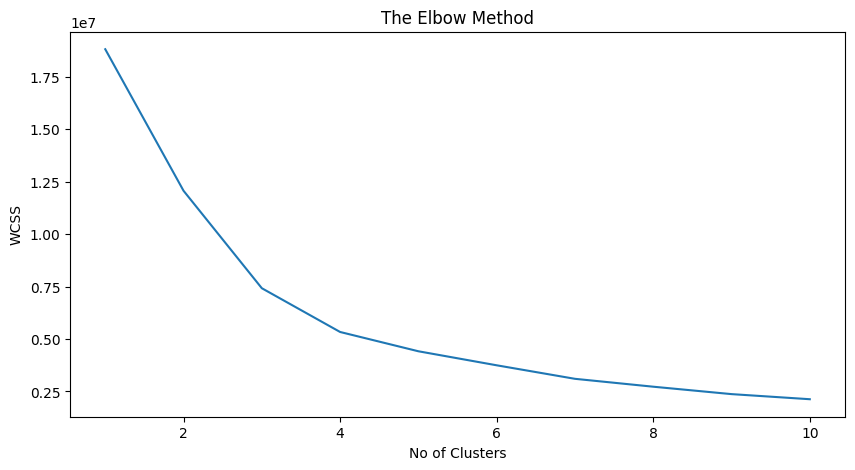

In [24]:
plt.plot(range(1,11), wcss)
plt.title("The Elbow Method")
plt.xlabel("No of Clusters")
plt.ylabel("WCSS")
plt.show()

## Elbow Graph

The Elbow Method is used to determine the optimal number of clusters by plotting WCSS values against different cluster numbers. The point where the graph bends (elbow) indicates the optimal number of clusters.

In [26]:
km = KMeans(
    n_clusters=4,
    init='k-means++',
    max_iter=300,
    n_init=10,
    random_state=0
)

y_means = km.fit_predict(X)

In [29]:
a = df['label']

y_means = pd.DataFrame(y_means)

z = pd.concat([y_means, a], axis=1)

z = z.rename(columns={0:'cluster'})

In [30]:
print("Let's check the results after applying the K-Means Clustering Analysis\n")

print("Crops in First Cluster:")
print(z[z['cluster']==0]['label'].unique())

print("---------------------------------------------")

print("Crops in Second Cluster:")
print(z[z['cluster']==1]['label'].unique())

print("---------------------------------------------")

print("Crops in Third Cluster:")
print(z[z['cluster']==2]['label'].unique())

print("---------------------------------------------")

print("Crops in Fourth Cluster:")
print(z[z['cluster']==3]['label'].unique())

Let's check the results after applying the K-Means Clustering Analysis

Crops in First Cluster:
['grapes' 'apple']
---------------------------------------------
Crops in Second Cluster:
['maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans' 'mungbean'
 'blackgram' 'lentil' 'pomegranate' 'mango' 'orange' 'papaya' 'coconut']
---------------------------------------------
Crops in Third Cluster:
['maize' 'banana' 'watermelon' 'muskmelon' 'papaya' 'cotton' 'coffee']
---------------------------------------------
Crops in Fourth Cluster:
['rice' 'pigeonpeas' 'papaya' 'coconut' 'jute' 'coffee']


## Training the Model

The K-Means clustering algorithm groups similar crops based on agricultural features. Each crop is assigned to one of four clusters according to feature similarity.